<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20QGen008.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N = 256
x = np.linspace(0, 2*np.pi, N, endpoint=False)
A = 0.1
sigma = 0.2
x0 = np.pi
phi0 = A * np.exp(-((x - x0)**2) / (2 * sigma**2))


In [2]:
dt = 0.02
gamma = 0.005
lam = 0.5
delta = 0.05
tau_vals = np.linspace(0.01, 0.2, 32)

def laplacian(phi):
    return np.roll(phi, 1) - 2*phi + np.roll(phi, -1)

def clip_guard(phi, max_abs=1.0):
    m = np.max(np.abs(phi))
    return phi * (max_abs / m) if m > max_abs else phi

def evolve(phi, tau, steps=250):
    for _ in range(steps):
        collapse = delta * (np.abs(phi) > tau)
        phi = phi + dt * (laplacian(phi) - gamma * phi + lam * phi**3) - collapse
        phi = clip_guard(phi)
    return phi

def correlation(a, b):
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return (np.dot(a, b) / denom) if denom > 0 else 0.0

def collapse_index(phi, eps=1e-3):
    return np.sum(np.abs(phi) < eps) / len(phi)

def revival_amplitude(phi):
    return np.max(np.abs(phi))

F_vals = []
C_vals = []
R_vals = []

for tau in tau_vals:
    phi = evolve(phi0.copy(), tau)
    F_vals.append(correlation(phi, phi0))
    C_vals.append(collapse_index(phi))
    R_vals.append(revival_amplitude(phi))


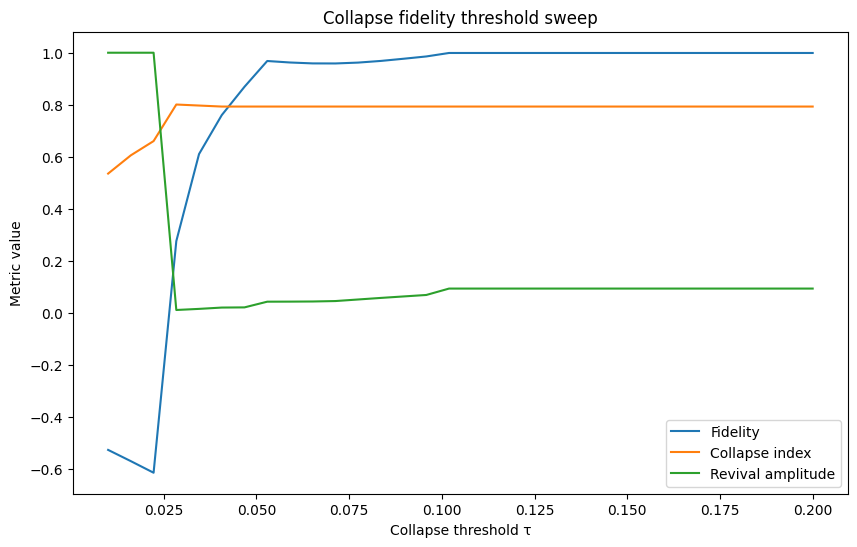

In [3]:
plt.figure(figsize=(10,6))
plt.plot(tau_vals, F_vals, label="Fidelity")
plt.plot(tau_vals, C_vals, label="Collapse index")
plt.plot(tau_vals, R_vals, label="Revival amplitude")
plt.xlabel("Collapse threshold τ")
plt.ylabel("Metric value")
plt.title("Collapse fidelity threshold sweep")
plt.legend()
plt.show()
